# NexusTrader Experiments — Persistent Scoring & Analysis Notebook

This notebook is redesigned for **reusable, persistent evaluation**.

What it guarantees each run:
1. Load raw JSONL agent outputs
2. Score every row consistently
3. Upsert scored rows into long-lived registries
4. Save timestamped analysis bundles (CSV + JSON + charts)
5. Keep comparisons reproducible across run tags

Use this as the single source of truth for experiment reporting.

In [1]:
from __future__ import annotations

import json
import random
from datetime import datetime, timedelta
from functools import lru_cache
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

plt.style.use("dark_background")
pd.set_option("display.max_columns", 200)

## 1) Global Configuration

In [ ]:
ROOT = Path(r"c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments")
RAW_DIR = ROOT / "results" / "raw"
SCORED_DIR = ROOT / "results" / "scored"
CHART_DIR = ROOT / "results" / "charts"
REPORT_DIR = ROOT / "results" / "analysis_reports"

SCORED_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

HORIZON_MAP = {"short": 10, "medium": 21, "long": 126}
HOLD_EPSILON = 0.05
RANDOM_SEED = 42

# Use one file or a glob pattern like "batch_eval50_v1.5_*.jsonl"
AGENT_RUN_GLOB = "batch_eval50_stageA_v4_20260304_210159.jsonl"

# Baseline controls
ENABLE_BASELINES = True

print("RAW_DIR:", RAW_DIR)
print("Matched agent JSONL files:", len(list(RAW_DIR.glob(AGENT_RUN_GLOB))))

RAW_DIR: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\raw
Matched agent JSONL files: 1


## 2) Core Helpers (Price Fetch, Scoring, Parsing)

In [3]:
import re
import yfinance as yf

@lru_cache(maxsize=4096)
def get_close_series(ticker: str, start_iso: str, end_iso: str):
    hist = yf.Ticker(ticker).history(start=start_iso, end=end_iso, auto_adjust=True)
    if hist.empty:
        return None
    s = hist["Close"].dropna()
    return s

def k_return(ticker: str, as_of: str, k: int):
    t0 = datetime.fromisoformat(as_of)
    t1 = t0 + timedelta(days=max(14, 4 * k))
    s = get_close_series(ticker, t0.date().isoformat(), t1.date().isoformat())
    if s is None or len(s) <= k:
        return np.nan
    p0 = float(s.iloc[0])
    pk = float(s.iloc[k])
    if p0 == 0:
        return np.nan
    return (pk - p0) / p0

def directional_correct(action: str, ret: float, hold_epsilon: float = HOLD_EPSILON):
    if pd.isna(ret):
        return np.nan
    a = (action or "HOLD").upper()
    if a == "BUY":
        return 1 if ret > 0 else 0
    if a == "SELL":
        return 1 if ret < 0 else 0
    if a == "HOLD":
        return 1 if abs(ret) < hold_epsilon else 0
    return np.nan

def true_direction_label(ret: float, hold_epsilon: float = HOLD_EPSILON):
    if pd.isna(ret):
        return np.nan
    if abs(ret) < hold_epsilon:
        return "HOLD"
    return "BUY" if ret > 0 else "SELL"

def extract_agent_action(obj: dict):
    result = obj.get("result", {}) if isinstance(obj, dict) else {}
    ts = result.get("trading_strategy", {}) if isinstance(result, dict) else {}
    return (ts.get("action") or "HOLD").upper()

def extract_confidence_band(obj: dict):
    result = obj.get("result", {}) if isinstance(obj, dict) else {}
    ts = result.get("trading_strategy", {}) if isinstance(result, dict) else {}
    rationale = (ts.get("rationale") or "")
    m = re.search(r"CONFIDENCE\s*[=:]\s*(LOW|MEDIUM|HIGH)", rationale, re.IGNORECASE)
    if m:
        return m.group(1).upper()
    m2 = re.search(r"confidence\s*band\s*[:=]\s*(LOW|MEDIUM|HIGH)", rationale, re.IGNORECASE)
    if m2:
        return m2.group(1).upper()
    return "UNKNOWN"

def parse_tag_and_timestamp(filename: str):
    stem = Path(filename).stem
    parts = stem.split("_")
    if len(parts) < 4:
        return stem, "unknown"
    ts = "_".join(parts[-2:])
    tag = "_".join(parts[1:-2])
    return tag, ts

## 3) Load Agent JSONL and Persist Scored Registry

In [4]:
def load_agent_runs(raw_dir: Path, pattern: str):
    rows = []
    for p in sorted(raw_dir.glob(pattern)):
        run_tag, run_ts = parse_tag_and_timestamp(p.name)
        with p.open("r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                obj = json.loads(line)
                if "error" in obj:
                    continue

                ticker = obj.get("ticker")
                simulated_date = obj.get("simulated_date")
                horizon = obj.get("horizon", "short")
                k = HORIZON_MAP.get(horizon, 10)
                action = extract_agent_action(obj)
                ret = k_return(ticker, simulated_date, k)

                rows.append({
                    "source": "agent",
                    "strategy": "nexustrader",
                    "run_file": p.name,
                    "run_tag": run_tag,
                    "run_timestamp": run_ts,
                    "ticker": ticker,
                    "simulated_date": simulated_date,
                    "horizon": horizon,
                    "k": int(k),
                    "action": action,
                    "k_return": ret,
                    "correct": directional_correct(action, ret),
                    "true_label": true_direction_label(ret),
                    "confidence_band": extract_confidence_band(obj),
                })

    return pd.DataFrame(rows)

AGENT_REGISTRY_PATH = SCORED_DIR / "agent_runs_scored_registry.csv"
incoming_agent_df = load_agent_runs(RAW_DIR, AGENT_RUN_GLOB)

if AGENT_REGISTRY_PATH.exists():
    agent_registry_df = pd.read_csv(AGENT_REGISTRY_PATH)
else:
    agent_registry_df = pd.DataFrame(columns=incoming_agent_df.columns)

if not incoming_agent_df.empty:
    agent_registry_df = pd.concat([agent_registry_df, incoming_agent_df], ignore_index=True)
    key_cols = ["run_file", "ticker", "simulated_date", "horizon", "k", "action"]
    agent_registry_df = agent_registry_df.drop_duplicates(subset=key_cols, keep="last").reset_index(drop=True)
    agent_registry_df.to_csv(AGENT_REGISTRY_PATH, index=False)

analysis_agent_df = incoming_agent_df.copy() if not incoming_agent_df.empty else agent_registry_df.copy()

print("Incoming rows:", len(incoming_agent_df))
print("Registry rows:", len(agent_registry_df))
print("Analysis rows:", len(analysis_agent_df))
print("Saved registry:", AGENT_REGISTRY_PATH)
display(analysis_agent_df.head(3))

Incoming rows: 125
Registry rows: 797
Analysis rows: 125
Saved registry: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\scored\agent_runs_scored_registry.csv


,source,strategy,run_file,run_tag,run_timestamp,ticker,simulated_date,horizon,k,action,k_return,correct,true_label,confidence_band
0,agent,nexustrader,batch_eval50_stageA_v4_20260304_210159.jsonl,eval50_stageA_v4,20260304_210159,AAPL,2022-09-26,short,10,HOLD,-0.068647,1,HOLD,MEDIUM
1,agent,nexustrader,batch_eval50_stageA_v4_20260304_210159.jsonl,eval50_stageA_v4,20260304_210159,AAPL,2021-10-25,short,10,HOLD,0.013587,1,HOLD,UNKNOWN
2,agent,nexustrader,batch_eval50_stageA_v4_20260304_210159.jsonl,eval50_stageA_v4,20260304_210159,AAPL,2022-02-28,short,10,HOLD,-0.087815,0,SELL,MEDIUM


## 4) Build Universe and Optional Baselines

In [5]:
if analysis_agent_df.empty:
    raise RuntimeError("No agent rows available. Check AGENT_RUN_GLOB and raw files.")

universe = (
    analysis_agent_df[["ticker", "simulated_date", "horizon", "k"]]
    .drop_duplicates()
    .sort_values(["ticker", "simulated_date", "horizon"])
    .reset_index(drop=True)
)

n_tickers = universe["ticker"].nunique()
n_dates = universe["simulated_date"].nunique()
print(f"Universe rows={len(universe)}, tickers={n_tickers}, dates={n_dates}, tickers*dates={n_tickers*n_dates}")
display(universe.head(10))

Universe rows=125, tickers=5, dates=25, tickers*dates=125


,ticker,simulated_date,horizon,k
0,AAPL,2021-10-25,short,10
1,AAPL,2021-11-15,short,10
2,AAPL,2021-12-27,short,10
3,AAPL,2022-01-17,short,10
4,AAPL,2022-02-07,short,10
5,AAPL,2022-02-28,short,10
6,AAPL,2022-04-11,short,10
7,AAPL,2022-08-15,short,10
8,AAPL,2022-09-26,short,10
9,AAPL,2022-10-17,short,10


## 5) Baseline Definitions and Baseline Registry

In [6]:
def baseline_buy_hold(_ticker: str, _date: str):
    return "BUY"

def baseline_sma(ticker: str, date: str, short_w: int = 20, long_w: int = 50):
    t = datetime.fromisoformat(date)
    s = get_close_series(ticker, (t - timedelta(days=3 * long_w)).date().isoformat(), t.date().isoformat())
    if s is None or len(s) < long_w:
        return "HOLD"
    sma_s = s.tail(short_w).mean()
    sma_l = s.tail(long_w).mean()
    if sma_s > 1.01 * sma_l:
        return "BUY"
    if sma_s < 0.99 * sma_l:
        return "SELL"
    return "HOLD"

def baseline_rsi(ticker: str, date: str, period: int = 14):
    t = datetime.fromisoformat(date)
    s = get_close_series(ticker, (t - timedelta(days=6 * period)).date().isoformat(), t.date().isoformat())
    if s is None or len(s) < period + 1:
        return "HOLD"
    d = s.diff().dropna()
    up = d.clip(lower=0).tail(period).mean()
    dn = (-d.clip(upper=0)).tail(period).mean()
    rs = up / (dn + 1e-9)
    rsi = 100 - (100 / (1 + rs))
    if rsi < 30:
        return "BUY"
    if rsi > 70:
        return "SELL"
    return "HOLD"

_rng = random.Random(RANDOM_SEED)
def baseline_random(_ticker: str, _date: str):
    return _rng.choice(["BUY", "SELL", "HOLD"])

## 6) Compute/Upsert Baselines (Optional)

In [7]:
baseline_specs = {
    "buy_hold": baseline_buy_hold,
    "sma_crossover": baseline_sma,
    "rsi_14": baseline_rsi,
    "random_uniform": baseline_random,
}

BASELINE_REGISTRY_PATH = SCORED_DIR / "baselines_registry.csv"
baseline_df = pd.DataFrame()

if ENABLE_BASELINES:
    if BASELINE_REGISTRY_PATH.exists():
        baseline_registry_df = pd.read_csv(BASELINE_REGISTRY_PATH)
    else:
        baseline_registry_df = pd.DataFrame(columns=[
            "source", "strategy", "run_file", "run_tag", "run_timestamp",
            "ticker", "simulated_date", "horizon", "k", "action", "k_return", "correct", "true_label", "confidence_band"
        ])

    needed = (
        universe.assign(_tmp=1)
        .merge(pd.DataFrame({"strategy": list(baseline_specs.keys()), "_tmp": 1}), on="_tmp")
        .drop(columns="_tmp")[["strategy", "ticker", "simulated_date", "horizon", "k"]]
        .reset_index(drop=True)
    )

    existing_keys = baseline_registry_df[["strategy", "ticker", "simulated_date", "horizon", "k"]].drop_duplicates() if not baseline_registry_df.empty else pd.DataFrame(columns=["strategy", "ticker", "simulated_date", "horizon", "k"])
    missing = needed.merge(existing_keys, on=["strategy", "ticker", "simulated_date", "horizon", "k"], how="left", indicator=True)
    missing = missing[missing["_merge"].eq("left_only")].drop(columns="_merge")

    new_rows = []
    for r in missing.itertuples(index=False):
        fn = baseline_specs[r.strategy]
        action = fn(r.ticker, r.simulated_date)
        ret = k_return(r.ticker, r.simulated_date, int(r.k))
        new_rows.append({
            "source": "baseline",
            "strategy": r.strategy,
            "run_file": "baseline_recomputed",
            "run_tag": "baseline",
            "run_timestamp": datetime.now().strftime("%Y%m%d_%H%M%S"),
            "ticker": r.ticker,
            "simulated_date": r.simulated_date,
            "horizon": r.horizon,
            "k": int(r.k),
            "action": action,
            "k_return": ret,
            "correct": directional_correct(action, ret),
            "true_label": true_direction_label(ret),
            "confidence_band": "N/A",
        })

    new_baselines_df = pd.DataFrame(new_rows)
    baseline_registry_df = pd.concat([baseline_registry_df, new_baselines_df], ignore_index=True)
    baseline_registry_df = baseline_registry_df.drop_duplicates(subset=["strategy", "ticker", "simulated_date", "horizon", "k"], keep="last").reset_index(drop=True)
    baseline_registry_df.to_csv(BASELINE_REGISTRY_PATH, index=False)

    baseline_df = baseline_registry_df.merge(
        universe[["ticker", "simulated_date", "horizon", "k"]].drop_duplicates(),
        on=["ticker", "simulated_date", "horizon", "k"],
        how="inner"
    ).reset_index(drop=True)

    print("Baseline rows used:", len(baseline_df), "| New rows computed:", len(new_baselines_df))
    print("Saved registry:", BASELINE_REGISTRY_PATH)
else:
    print("Baselines disabled.")

Baseline rows used: 500 | New rows computed: 0
Saved registry: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\scored\baselines_registry.csv


## 7) Reusable Analysis Functions (Primary + Secondary Metrics)

In [8]:
def directional_accuracy_ex_hold(df: pd.DataFrame):
    d = df[df["action"].isin(["BUY", "SELL"])].copy()
    if d.empty:
        return np.nan, 0
    acc = d["correct"].mean() * 100
    return acc, len(d)

def hold_quality(df: pd.DataFrame, eps: float = HOLD_EPSILON):
    h = df[df["action"].eq("HOLD")].copy()
    if h.empty:
        return {"hold_n": 0, "hold_rate_%": 0.0, "hold_precision_%": np.nan, "hold_far_miss_n": 0}
    h["abs_ret"] = h["k_return"].abs()
    hold_precision = (h["abs_ret"] < eps).mean() * 100
    return {
        "hold_n": int(len(h)),
        "hold_rate_%": len(h) / max(len(df), 1) * 100,
        "hold_precision_%": hold_precision,
        "hold_far_miss_n": int((h["abs_ret"] >= eps).sum()),
    }

def strategy_return_series(df: pd.DataFrame):
    d = df.copy()
    d["strategy_return"] = np.where(
        d["action"].eq("BUY"), d["k_return"],
        np.where(d["action"].eq("SELL"), -d["k_return"], 0.0)
    )
    d["buy_hold_return"] = d["k_return"]
    d["excess_vs_buy_hold"] = d["strategy_return"] - d["buy_hold_return"]
    return d

def summarize_group(df: pd.DataFrame, group_col: str):
    out = []
    for name, g in df.groupby(group_col):
        dacc, dacc_n = directional_accuracy_ex_hold(g)
        hold = hold_quality(g)
        ret_df = strategy_return_series(g.dropna(subset=["k_return"]).copy())

        out.append({
            "name": name,
            "n": int(len(g)),
            "overall_acc_%": round(g["correct"].mean() * 100, 2),
            "dir_acc_ex_hold_%": round(dacc, 2) if not pd.isna(dacc) else np.nan,
            "dir_acc_ex_hold_n": int(dacc_n),
            "buy_acc_%": round(g.loc[g.action.eq("BUY"), "correct"].mean() * 100, 2) if (g.action == "BUY").any() else np.nan,
            "sell_acc_%": round(g.loc[g.action.eq("SELL"), "correct"].mean() * 100, 2) if (g.action == "SELL").any() else np.nan,
            "hold_acc_%": round(g.loc[g.action.eq("HOLD"), "correct"].mean() * 100, 2) if (g.action == "HOLD").any() else np.nan,
            "buy_n": int((g.action == "BUY").sum()),
            "sell_n": int((g.action == "SELL").sum()),
            "hold_n": hold["hold_n"],
            "hold_rate_%": round(hold["hold_rate_%"], 2),
            "hold_precision_%": round(hold["hold_precision_%"], 2) if not pd.isna(hold["hold_precision_%"]) else np.nan,
            "mean_strategy_return_%": round(ret_df["strategy_return"].mean() * 100, 3) if not ret_df.empty else np.nan,
            "mean_excess_vs_bh_%": round(ret_df["excess_vs_buy_hold"].mean() * 100, 3) if not ret_df.empty else np.nan,
        })
    return pd.DataFrame(out).sort_values(["dir_acc_ex_hold_%", "overall_acc_%"], ascending=False).reset_index(drop=True)

def bootstrap_ci_mean(x, n_boot=5000, ci=95, seed=42):
    x = np.asarray(pd.Series(x).dropna(), dtype=float)
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    means = np.empty(n_boot)
    n = len(x)
    for i in range(n_boot):
        means[i] = rng.choice(x, size=n, replace=True).mean()
    alpha = (100 - ci) / 2
    lo = float(np.percentile(means, alpha))
    hi = float(np.percentile(means, 100 - alpha))
    return float(x.mean()), lo, hi

## 8) Build Current Analysis and Save Bundle

In [9]:
agent_summary = summarize_group(analysis_agent_df, "run_tag")
baseline_summary = summarize_group(baseline_df, "strategy") if ENABLE_BASELINES and not baseline_df.empty else pd.DataFrame()

display(agent_summary)
if not baseline_summary.empty:
    display(baseline_summary)

analysis_ts = datetime.now().strftime("%Y%m%d_%H%M%S")
bundle_dir = REPORT_DIR / f"analysis_{analysis_ts}"
bundle_dir.mkdir(parents=True, exist_ok=True)

agent_rows_path = bundle_dir / "agent_rows_scored.csv"
agent_summary_path = bundle_dir / "agent_summary.csv"
analysis_agent_df.to_csv(agent_rows_path, index=False)
agent_summary.to_csv(agent_summary_path, index=False)

if not baseline_summary.empty:
    baseline_rows_path = bundle_dir / "baseline_rows_scored.csv"
    baseline_summary_path = bundle_dir / "baseline_summary.csv"
    baseline_df.to_csv(baseline_rows_path, index=False)
    baseline_summary.to_csv(baseline_summary_path, index=False)

meta = {
    "created_at": analysis_ts,
    "agent_glob": AGENT_RUN_GLOB,
    "agent_rows": int(len(analysis_agent_df)),
    "unique_tickers": int(analysis_agent_df["ticker"].nunique()) if not analysis_agent_df.empty else 0,
    "unique_dates": int(analysis_agent_df["simulated_date"].nunique()) if not analysis_agent_df.empty else 0,
    "hold_epsilon": HOLD_EPSILON,
    "enable_baselines": ENABLE_BASELINES,
}
with (bundle_dir / "meta.json").open("w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

print("Saved analysis bundle:", bundle_dir)
print("-", agent_rows_path.name)
print("-", agent_summary_path.name)
if ENABLE_BASELINES and not baseline_summary.empty:
    print("- baseline rows/summary")

,name,n,overall_acc_%,dir_acc_ex_hold_%,dir_acc_ex_hold_n,buy_acc_%,sell_acc_%,hold_acc_%,buy_n,sell_n,hold_n,hold_rate_%,hold_precision_%,mean_strategy_return_%,mean_excess_vs_bh_%
0,eval50_stageA_v4,125,62.4,56.14,57,54.0,71.43,67.65,50,7,68,54.4,67.65,0.496,-0.669


,name,n,overall_acc_%,dir_acc_ex_hold_%,dir_acc_ex_hold_n,buy_acc_%,sell_acc_%,hold_acc_%,buy_n,sell_n,hold_n,hold_rate_%,hold_precision_%,mean_strategy_return_%,mean_excess_vs_bh_%
0,buy_hold,125,54.4,54.40,125,54.40,NaN,NaN,125,0,0,0.0,NaN,1.165,0.000
1,sma_crossover,125,50.4,53.85,104,55.93,51.11,33.33,59,45,21,16.8,76.19,0.215,-0.950
2,rsi_14,125,32.0,45.71,35,60.00,35.00,26.67,15,20,90,72.0,66.67,-0.224,-1.389
3,random_uniform,125,40.0,43.37,83,47.83,37.84,33.33,46,37,42,33.6,71.43,-0.266,-1.431


Saved analysis bundle: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\analysis_reports\analysis_20260304_212650
- agent_rows_scored.csv
- agent_summary.csv
- baseline rows/summary


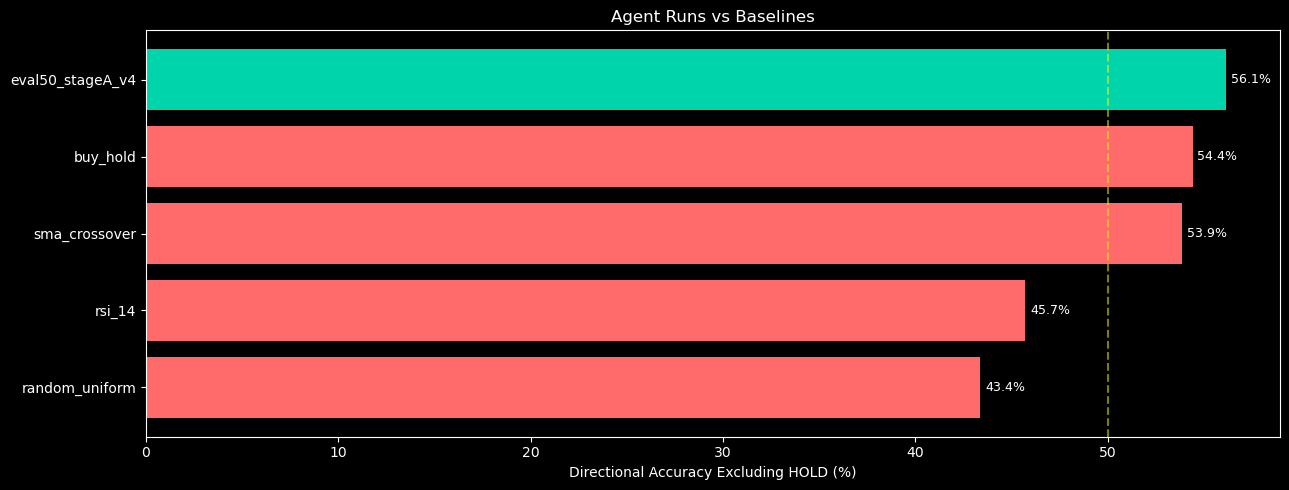

Saved: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\analysis_reports\analysis_20260304_212650\chart_dir_acc_ex_hold.png


In [10]:
plot_df = pd.DataFrame()
if not agent_summary.empty:
    plot_df = pd.concat([plot_df, agent_summary.assign(group="agent")[["name", "dir_acc_ex_hold_%", "group"]]], ignore_index=True)
if not baseline_summary.empty:
    plot_df = pd.concat([plot_df, baseline_summary.assign(group="baseline")[["name", "dir_acc_ex_hold_%", "group"]]], ignore_index=True)

plot_df = plot_df.dropna(subset=["dir_acc_ex_hold_%"]).sort_values("dir_acc_ex_hold_%", ascending=True).reset_index(drop=True)

if not plot_df.empty:
    fig, ax = plt.subplots(figsize=(13, max(5, 0.55 * len(plot_df))))
    colors = ["#00d4aa" if g == "agent" else "#ff6b6b" for g in plot_df["group"]]
    ax.barh(plot_df["name"], plot_df["dir_acc_ex_hold_%"], color=colors)
    ax.axvline(50, color="yellow", linestyle="--", alpha=0.5)
    ax.set_xlabel("Directional Accuracy Excluding HOLD (%)")
    ax.set_title("Agent Runs vs Baselines")
    for y, v in enumerate(plot_df["dir_acc_ex_hold_%"]):
        ax.text(v + 0.25, y, f"{v:.1f}%", va="center", fontsize=9)
    plt.tight_layout()
    chart_path = bundle_dir / "chart_dir_acc_ex_hold.png"
    plt.savefig(chart_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", chart_path)
else:
    print("No rows to plot.")

## 9) Paired Run Comparison (Same Ticker/Date/Horizon)

In [11]:
# Pick tags for paired comparison
curr_tag = agent_summary.iloc[0]["name"] if not agent_summary.empty else None
prev_tag = None  # set manually, e.g. "eval50_v1.2_gm-3-f_risk-on"

registry_df = pd.read_csv(AGENT_REGISTRY_PATH) if AGENT_REGISTRY_PATH.exists() else analysis_agent_df.copy()

if curr_tag is None:
    print("No current run available.")
elif prev_tag is None:
    print("Set prev_tag to enable paired comparison.")
else:
    curr = registry_df[registry_df["run_tag"].eq(curr_tag)].copy()
    prev = registry_df[registry_df["run_tag"].eq(prev_tag)].copy()
    keys = ["ticker", "simulated_date", "horizon"]

    keep_cols = keys + ["action", "k_return", "correct"]
    c = curr[keep_cols].rename(columns={"action": "action_curr", "k_return": "k_return_curr", "correct": "correct_curr"})
    p = prev[keep_cols].rename(columns={"action": "action_prev", "k_return": "k_return_prev", "correct": "correct_prev"})

    paired = c.merge(p, on=keys, how="inner")
    print(f"curr={curr_tag} rows={len(c)} | prev={prev_tag} rows={len(p)} | overlap={len(paired)}")

    if not paired.empty:
        paired["k_return"] = paired["k_return_curr"].fillna(paired["k_return_prev"])

        def strat_ret(action, kret):
            if pd.isna(kret):
                return np.nan
            if action == "BUY":
                return kret
            if action == "SELL":
                return -kret
            return 0.0

        paired["ret_curr"] = [strat_ret(a, r) for a, r in zip(paired["action_curr"], paired["k_return"])]
        paired["ret_prev"] = [strat_ret(a, r) for a, r in zip(paired["action_prev"], paired["k_return"])]
        paired["excess_curr"] = paired["ret_curr"] - paired["k_return"]
        paired["excess_prev"] = paired["ret_prev"] - paired["k_return"]

        curr_dir = paired[paired["action_curr"].isin(["BUY", "SELL"])]["correct_curr"].mean() * 100
        prev_dir = paired[paired["action_prev"].isin(["BUY", "SELL"])]["correct_prev"].mean() * 100

        cmp = pd.DataFrame([
            ["overall_acc_%", paired["correct_curr"].mean() * 100, paired["correct_prev"].mean() * 100],
            ["dir_acc_ex_hold_%", curr_dir, prev_dir],
            ["hold_rate_%", paired["action_curr"].eq("HOLD").mean() * 100, paired["action_prev"].eq("HOLD").mean() * 100],
            ["mean_strategy_return_%", paired["ret_curr"].mean() * 100, paired["ret_prev"].mean() * 100],
            ["mean_excess_vs_bh_%", paired["excess_curr"].mean() * 100, paired["excess_prev"].mean() * 100],
        ], columns=["metric", curr_tag, prev_tag])
        cmp["delta"] = cmp[curr_tag] - cmp[prev_tag]
        cmp = cmp.round(3)
        display(cmp)

        paired_out = bundle_dir / f"paired_{curr_tag}_vs_{prev_tag}.csv"
        cmp_out = bundle_dir / f"paired_summary_{curr_tag}_vs_{prev_tag}.csv"
        paired.to_csv(paired_out, index=False)
        cmp.to_csv(cmp_out, index=False)
        print("Saved:", paired_out.name)
        print("Saved:", cmp_out.name)

Set prev_tag to enable paired comparison.


## 10) Confidence-Band Diagnostics (Calibration View)

In [1]:
conf_df = analysis_agent_df.copy()
conf_stats = (
    conf_df.groupby("confidence_band")
    .agg(
        n=("correct", "size"),
        overall_acc_%=("correct", lambda s: s.mean() * 100),
        hold_rate_%=("action", lambda s: (s == "HOLD").mean() * 100),
    )
    .reset_index()
    .sort_values("n", ascending=False)
)

# directional-only accuracy per confidence
rows = []
for cb, g in conf_df.groupby("confidence_band"):
    dacc, dn = directional_accuracy_ex_hold(g)
    rows.append({
        "confidence_band": cb,
        "dir_acc_ex_hold_%": dacc,
        "dir_acc_ex_hold_n": dn,
    })
dir_conf = pd.DataFrame(rows)

conf_stats = conf_stats.merge(dir_conf, on="confidence_band", how="left")
conf_stats = conf_stats.round(3)
display(conf_stats)

conf_path = bundle_dir / "confidence_diagnostics.csv"
conf_stats.to_csv(conf_path, index=False)
print("Saved:", conf_path)

if not conf_stats.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    x = conf_stats["confidence_band"].astype(str)
    y = conf_stats["dir_acc_ex_hold_%"]
    ax.bar(x, y, color="#7aa2f7")
    ax.axhline(50, color="yellow", linestyle="--", alpha=0.6)
    ax.set_ylabel("Directional Accuracy Excluding HOLD (%)")
    ax.set_title("Calibration by Confidence Band")
    plt.tight_layout()
    conf_chart = bundle_dir / "chart_confidence_calibration.png"
    plt.savefig(conf_chart, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", conf_chart)

SyntaxError: positional argument follows keyword argument (672039495.py, line 6)

## 10B) Stage-Level Diagnostics (Per-Ticker + Prompt Pattern Quality)

In [11]:
import re


def load_raw_decision_details(raw_dir: Path, pattern: str):
    rows = []
    for p in sorted(raw_dir.glob(pattern)):
        with p.open("r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                obj = json.loads(line)
                if "error" in obj:
                    continue

                ts = ((obj.get("result") or {}).get("trading_strategy") or {})
                rationale = ts.get("rationale") or ""
                rows.append({
                    "run_file": p.name,
                    "ticker": obj.get("ticker"),
                    "simulated_date": obj.get("simulated_date"),
                    "action": (ts.get("action") or "HOLD").upper(),
                    "confidence_score": float(ts.get("confidence_score")) if ts.get("confidence_score") is not None else np.nan,
                    "rationale": rationale,
                    "has_hedge": bool(re.search(r"\b(while|despite|although|however|but)\b", rationale, re.IGNORECASE)),
                    "has_level": bool(re.search(r"\b(support|resistance|sma|bollinger|rsi|macd)\b", rationale, re.IGNORECASE)),
                    "has_fund": bool(re.search(r"\b(revenue|margin|income|cash\s*flow|guidance|growth)\b", rationale, re.IGNORECASE)),
                    "has_risk": bool(re.search(r"\b(risk|uncertain|volatility|headwind|overbought|oversold)\b", rationale, re.IGNORECASE)),
                })
    return pd.DataFrame(rows)


raw_decisions_df = load_raw_decision_details(RAW_DIR, AGENT_RUN_GLOB)

merge_keys = ["run_file", "ticker", "simulated_date", "action"]
analysis_cols = merge_keys + ["correct", "k_return", "run_tag", "horizon", "k"]

if not raw_decisions_df.empty and not analysis_agent_df.empty:
    stage_diag_df = raw_decisions_df.merge(
        analysis_agent_df[analysis_cols],
        on=merge_keys,
        how="left"
    )
else:
    stage_diag_df = pd.DataFrame()

if stage_diag_df.empty:
    print("No stage diagnostic rows available.")
else:
    per_ticker = (
        stage_diag_df.groupby("ticker")
        .agg(
            n=("correct", "size"),
            acc_pct=("correct", lambda s: s.mean() * 100),
            buy_n=("action", lambda s: (s == "BUY").sum()),
            sell_n=("action", lambda s: (s == "SELL").sum()),
            hold_n=("action", lambda s: (s == "HOLD").sum()),
            mean_confidence=("confidence_score", "mean"),
        )
        .reset_index()
        .sort_values("acc_pct", ascending=False)
        .rename(columns={"acc_pct": "acc_%"})
    )
    per_ticker = per_ticker.round({"acc_%": 2, "mean_confidence": 3})

    marker_cols = ["has_hedge", "has_level", "has_fund", "has_risk"]
    marker_rows = []
    for marker in marker_cols:
        for present in [True, False]:
            g = stage_diag_df[stage_diag_df[marker] == present]
            marker_rows.append({
                "marker": marker,
                "present": present,
                "n": int(len(g)),
                "acc_%": round(g["correct"].mean() * 100, 2) if not g.empty else np.nan,
                "mean_confidence": round(g["confidence_score"].mean(), 3) if not g.empty else np.nan,
            })
    marker_stats = pd.DataFrame(marker_rows).sort_values(["marker", "present"], ascending=[True, False])

    wrong_calls = stage_diag_df[stage_diag_df["correct"].eq(0)].copy()
    wrong_calls["abs_k_return"] = wrong_calls["k_return"].abs()
    worst_misses = wrong_calls.sort_values("abs_k_return", ascending=False).head(15)

    high_conf = stage_diag_df[stage_diag_df["confidence_score"] >= 0.75]
    print("Rows:", len(stage_diag_df))
    print("High-confidence rows (>=0.75):", len(high_conf), "| Accuracy:", round(high_conf["correct"].mean() * 100, 2) if not high_conf.empty else np.nan)

    display(per_ticker)
    display(marker_stats)
    display(worst_misses[["ticker", "simulated_date", "action", "confidence_score", "k_return", "rationale"]].head(10))

    if "bundle_dir" in globals() and bundle_dir.exists():
        per_ticker_path = bundle_dir / "stage_per_ticker_accuracy.csv"
        marker_path = bundle_dir / "stage_prompt_marker_quality.csv"
        misses_path = bundle_dir / "stage_top_wrong_calls.csv"

        per_ticker.to_csv(per_ticker_path, index=False)
        marker_stats.to_csv(marker_path, index=False)
        worst_misses.to_csv(misses_path, index=False)

        print("Saved:", per_ticker_path)
        print("Saved:", marker_path)
        print("Saved:", misses_path)


Rows: 125
High-confidence rows (>=0.75): 8 | Accuracy: 50.0


,ticker,n,acc_%,buy_n,sell_n,hold_n,mean_confidence
1,JNJ,25,76.0,6,3,16,0.595
4,XOM,25,76.0,10,0,15,0.609
0,AAPL,25,56.0,10,0,15,0.607
2,JPM,25,56.0,8,2,15,0.598
3,NVDA,25,48.0,16,2,7,0.689


,marker,present,n,acc_%,mean_confidence
4,has_fund,True,114,60.53,0.617
5,has_fund,False,11,81.82,0.647
0,has_hedge,True,12,66.67,0.615
1,has_hedge,False,113,61.95,0.620
2,has_level,True,111,63.96,0.620
3,has_level,False,14,50.00,0.621
6,has_risk,True,36,63.89,0.632
7,has_risk,False,89,61.80,0.615


,ticker,simulated_date,action,confidence_score,k_return,rationale
71,NVDA,2021-10-25,HOLD,0.55,0.329707,FOR: Strong fundamental revenue growth of 14.9...
80,NVDA,2023-01-09,HOLD,0.55,0.232723,FOR: Sustained revenue deceleration and signif...
91,NVDA,2025-02-24,BUY,0.68,-0.178846,FOR: Strong financial performance with 12.1% Q...
105,XOM,2022-09-26,HOLD,0.55,0.176947,FOR: Strong fundamental performance with 26.8%...
78,NVDA,2022-04-11,HOLD,0.52,-0.142766,FOR: Strong fundamental performance with net i...
81,NVDA,2022-10-17,SELL,0.68,0.135347,FOR: Sharp fundamental deterioration with a 19...
75,NVDA,2022-02-28,BUY,0.72,-0.125133,FOR: Record $7.64B quarterly sales and doubled...
112,NVDA,2021-12-27,HOLD,0.55,-0.114558,FOR: Strong top-line momentum with revenue rea...
64,JPM,2025-02-24,HOLD,0.55,-0.111426,FOR: Bearish technical momentum is confirmed b...
97,XOM,2021-12-27,HOLD,0.55,0.106318,FOR: Strong Q3 revenue growth of 9% QoQ and a ...


Saved: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\analysis_reports\analysis_20260304_212650\stage_per_ticker_accuracy.csv
Saved: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\analysis_reports\analysis_20260304_212650\stage_prompt_marker_quality.csv
Saved: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\analysis_reports\analysis_20260304_212650\stage_top_wrong_calls.csv


In [23]:
# Ultra-compact: just action vs market direction
for t in ["JNJ", "NVDA"]:
    tf = stage_diag_df[stage_diag_df.ticker == t].sort_values("simulated_date")
    print(f"\n{t} (acc={tf.correct.mean()*100:.0f}%)")
    for _, r in tf.iterrows():
        mark = "OK" if r.correct == 1 else "XX"
        true_dir = "UP" if r.k_return > 0 else "DN"
        print(f"  [{mark}] {r.simulated_date} call={r.action} mkt={true_dir}({r.k_return*100:+.1f}%) conf={r.confidence_score:.2f}")

nvda = stage_diag_df[stage_diag_df.ticker == "NVDA"]
jnj = stage_diag_df[stage_diag_df.ticker == "JNJ"]
print(f"\nNVDA: BUY={sum(nvda.action=='BUY')} SELL={sum(nvda.action=='SELL')} | mkt UP={sum(nvda.k_return>0)} DN={sum(nvda.k_return<0)}")
print(f"JNJ:  BUY={sum(jnj.action=='BUY')} SELL={sum(jnj.action=='SELL')} | mkt UP={sum(jnj.k_return>0)} DN={sum(jnj.k_return<0)}")


JNJ (acc=40%)
  [XX] 2021-11-15 call=BUY mkt=DN(-4.0%) conf=0.75
  [OK] 2022-01-17 call=BUY mkt=UP(+2.3%) conf=0.65
  [OK] 2022-02-28 call=BUY mkt=UP(+4.3%) conf=0.65
  [XX] 2022-09-26 call=BUY mkt=DN(-3.2%) conf=0.70
  [OK] 2023-05-15 call=SELL mkt=DN(-2.5%) conf=0.85
  [XX] 2023-10-30 call=SELL mkt=UP(+0.4%) conf=0.70
  [OK] 2024-12-02 call=SELL mkt=DN(-7.1%) conf=0.70
  [XX] 2025-02-24 call=SELL mkt=UP(+2.4%) conf=0.75
  [XX] 2025-08-11 call=SELL mkt=UP(+2.6%) conf=0.70
  [XX] 2026-01-05 call=SELL mkt=UP(+6.8%) conf=0.75

NVDA (acc=40%)
  [OK] 2021-11-15 call=BUY mkt=UP(+8.8%) conf=0.75
  [XX] 2022-01-17 call=BUY mkt=DN(-4.9%) conf=0.60
  [XX] 2022-02-28 call=BUY mkt=DN(-12.5%) conf=0.70
  [OK] 2022-09-26 call=SELL mkt=DN(-4.6%) conf=0.85
  [OK] 2023-05-15 call=BUY mkt=UP(+38.5%) conf=0.80
  [OK] 2023-10-30 call=BUY mkt=UP(+18.1%) conf=0.70
  [XX] 2024-12-02 call=BUY mkt=DN(-4.8%) conf=0.70
  [XX] 2025-02-24 call=BUY mkt=DN(-17.9%) conf=0.70
  [XX] 2025-08-11 call=BUY mkt=DN(-1.2%)

## 10C) Stage A Optimizations — What Changed & Comparison Setup

Three targeted fixes were applied to Stage A (prompts only, no topology change):

| Layer | Before | After |
|---|---|---|
| **Research Manager** | Scored "evidence in debate" (but debate=off → empty source) | Scores from Signal Summary + Analyst Reports directly |
| **Research Manager** | Spread threshold = 1 (easy to flip on noise) | Spread threshold = **2** for Stage A |
| **Trader** | Single-sided: "decide from RM plan, prefer BUY/SELL" | **Two-sided + evidence gate**: requires 2/3 signals to agree; mandatory FOR/AGAINST before deciding |
| **Trader** | Anti-abstention guard forced HOLD → BUY/SELL | Guard **disabled for Stage A** |

Expected effects:
- NVDA over-BUY bias: 2-of-3 signal agreement gate should block BUY on bearish dates
- JNJ SELL drift: AGAINST clause + signal gate should surface the recovery signals
- Overall: more HOLD on ambiguous dates → higher directional accuracy on dates that do commit

In [28]:
# ── Stage A v1 vs v2 comparison ──────────────────────────────────────────────
# After running a new batch with the upgraded prompts, set V2_GLOB below and
# run this cell.  It auto-scores the new batch and prints a side-by-side table.
# ─────────────────────────────────────────────────────────────────────────────

V1_GLOB = "batch_eval50_stageA_v2_*.jsonl"   # baseline (today's run)
V2_GLOB = "batch_eval50_stageA_v3_*.jsonl"              # ← update after new batch

def score_batch(pattern: str) -> pd.DataFrame:
    rows = []
    for p in sorted(RAW_DIR.glob(pattern)):
        run_tag, _ = parse_tag_and_timestamp(p.name)
        with p.open("r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line or "error" in json.loads(line):
                    continue
                obj = json.loads(line)
                ticker = obj.get("ticker")
                sim_date = obj.get("simulated_date")
                horizon = obj.get("horizon", "short")
                k = HORIZON_MAP.get(horizon, 10)
                action = extract_agent_action(obj)
                ret = k_return(ticker, sim_date, k)
                ts = ((obj.get("result") or {}).get("trading_strategy") or {})
                conf = ts.get("confidence_score")
                rows.append({
                    "run_tag": run_tag, "ticker": ticker, "simulated_date": sim_date,
                    "action": action, "k_return": ret,
                    "correct": directional_correct(action, ret),
                    "confidence_score": float(conf) if conf is not None else np.nan,
                })
    return pd.DataFrame(rows)


def compare_batches(v1: pd.DataFrame, v2: pd.DataFrame, label_v1="v1", label_v2="v2"):
    rows = []
    for label, df in [(label_v1, v1), (label_v2, v2)]:
        if df.empty:
            continue
        dir_rows = df[df.action.isin(["BUY","SELL"])]
        rows.append({
            "version": label,
            "n": len(df),
            "overall_acc_%": round(df.correct.mean()*100, 2),
            "dir_acc_ex_hold_%": round(dir_rows.correct.mean()*100, 2) if not dir_rows.empty else np.nan,
            "hold_rate_%": round((df.action=="HOLD").mean()*100, 2),
            "buy_n": int((df.action=="BUY").sum()),
            "sell_n": int((df.action=="SELL").sum()),
            "hold_n": int((df.action=="HOLD").sum()),
            "mean_conf": round(df.confidence_score.mean(), 3),
        })

        # Per-ticker breakdown
        for t, g in df.groupby("ticker"):
            dr = g[g.action.isin(["BUY","SELL"])]
            rows[-1][f"{t}_acc"] = round(g.correct.mean()*100,1)

    cmp = pd.DataFrame(rows)
    return cmp


v1_df = score_batch(V1_GLOB)

# Load v2 if available, else show placeholder
v2_files = list(RAW_DIR.glob(V2_GLOB))
if v2_files:
    v2_df = score_batch(V2_GLOB)
    cmp = compare_batches(v1_df, v2_df, "stageA_v1 (old prompts)", "stageA_v2 (new prompts)")
    print("=== Stage A v1 vs v2 ===")
    display(cmp.T)
    # Per-ticker delta
    print("\n=== Per-ticker accuracy (v1 vs v2) ===")
    for t in ["AAPL", "NVDA", "JNJ", "JPM", "XOM"]:
        v1t = v1_df[v1_df.ticker==t]
        v2t = v2_df[v2_df.ticker==t]
        v1a = v1t.correct.mean()*100 if not v1t.empty else np.nan
        v2a = v2t.correct.mean()*100 if not v2t.empty else np.nan
        delta = (v2a - v1a) if not (pd.isna(v1a) or pd.isna(v2a)) else np.nan
        sign = "↑" if delta and delta > 0 else ("↓" if delta and delta < 0 else "→")
        print(f"  {t}: v1={v1a:.0f}%  v2={v2a:.0f}%  {sign}{abs(delta):.0f}pp" if not pd.isna(delta) else f"  {t}: v1={v1a:.0f}%  (v2 not available)")
else:
    print(f"V2 batch not found ({V2_GLOB}). Run a new batch with the updated prompts and set V2_GLOB.")
    print(f"\nV1 summary ({V1_GLOB}):")
    v1_cmp = compare_batches(v1_df, pd.DataFrame(), "stageA_v1")
    display(v1_cmp)

=== Stage A v1 vs v2 ===


,0,1
version,stageA_v1 (old prompts),stageA_v2 (new prompts)
n,50,50
overall_acc_%,38.0,30.0
dir_acc_ex_hold_%,54.55,40.0
hold_rate_%,56.0,70.0
buy_n,19,14
sell_n,3,1
hold_n,28,35
mean_conf,0.608,0.604
AAPL_acc,20.0,10.0



=== Per-ticker accuracy (v1 vs v2) ===
  AAPL: v1=20%  v2=10%  ↓10pp
  NVDA: v1=40%  v2=20%  ↓20pp
  JNJ: v1=30%  v2=30%  →0pp
  JPM: v1=50%  v2=40%  ↓10pp
  XOM: v1=50%  v2=50%  →0pp


## 11) Run Manifest + Export Index

In [12]:
artifact_files = sorted([p.name for p in bundle_dir.iterdir() if p.is_file()])

manifest = {
    "bundle_dir": str(bundle_dir),
    "created_at": analysis_ts,
    "artifact_count": len(artifact_files),
    "artifacts": artifact_files,
}

manifest_path = bundle_dir / "manifest.json"
with manifest_path.open("w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

display(pd.DataFrame({"artifact": artifact_files}))
print("Saved:", manifest_path)

,artifact
0,agent_rows_scored.csv
1,agent_summary.csv
2,baseline_rows_scored.csv
3,baseline_summary.csv
4,chart_dir_acc_ex_hold.png
5,meta.json


Saved: c:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\analysis_reports\analysis_20260303_160128\manifest.json


## 12) Quick Reuse Guide

In [ ]:
print("Reuse flow:")
print("1) Set AGENT_RUN_GLOB in Cell 4")
print("2) Run all cells top-to-bottom")
print("3) Find outputs in:", bundle_dir)
print("4) Use paired comparison by setting prev_tag in Cell 21")

print("\nPersistent stores updated:")
print("-", AGENT_REGISTRY_PATH)
if ENABLE_BASELINES:
    print("-", BASELINE_REGISTRY_PATH)

### Notes

- This notebook is now fully persistence-oriented.
- Every run writes a timestamped folder under `results/analysis_reports/analysis_YYYYMMDD_HHMMSS`.
- Long-lived registries are continuously upserted (agent + baselines).
- Primary metric is directional accuracy excluding HOLD; HOLD is tracked with separate quality metrics.